# Importing Libraries

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical tests
from scipy import stats

# Machine learning models and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, r2_score, roc_auc_score, roc_curve
)

# Ignore warnings (optional)
import warnings
warnings.filterwarnings('ignore')

# Display settings
%matplotlib inline
plt.style.use('seaborn')

# Loading the Dataset

In [2]:
# Load the datasets
df_low = pd.read_csv('/kaggle/input/spotify-music-dataset/low_popularity_spotify_data.csv')
df_high = pd.read_csv('/kaggle/input/spotify-music-dataset/high_popularity_spotify_data.csv')

# Add a label to identify low and high popularity songs
df_low['Popularity_Label'] = 'Low'
df_high['Popularity_Label'] = 'High'

# Combine the datasets
df = pd.concat([df_low, df_high], ignore_index=True)

# Display the first few rows
df.head()

,time_signature,track_popularity,speechiness,danceability,playlist_name,track_artist,duration_ms,energy,playlist_genre,playlist_subgenre,...,playlist_id,track_id,valence,key,tempo,loudness,acousticness,liveness,track_album_name,Popularity_Label
0,4.0,23,0.0393,0.636,Rock Classics,Creedence Clearwater Revival,138053.0,0.746,rock,classic,...,37i9dQZF1DWXRqgorJj26U,5e6x5YRnMJIKvYpZxLqdpH,0.432,0.0,132.310,-3.785,0.0648,0.1730,The Long Road Home - The Ultimate John Fogerty...,Low
1,4.0,53,0.0317,0.572,Rock Classics,Van Halen,241600.0,0.835,rock,classic,...,37i9dQZF1DWXRqgorJj26U,5FqYA8KfiwsQvyBI4IamnY,0.795,0.0,129.981,-6.219,0.1710,0.0702,The Collection,Low
2,4.0,55,0.0454,0.591,Rock Classics,Stevie Nicks,329413.0,0.804,rock,classic,...,37i9dQZF1DWXRqgorJj26U,5LNiqEqpDc8TuqPy79kDBu,0.658,0.0,111.457,-7.299,0.3270,0.0818,Bella Donna (Deluxe Edition),Low
3,4.0,64,0.1010,0.443,Jazz Classics,"Ella Fitzgerald, Louis Armstrong",185160.0,0.104,jazz,classic,...,37i9dQZF1DXbITWG1ZJKYt,78MI7mu1LV1k4IA2HzKmHe,0.394,0.0,76.474,-17.042,0.9130,0.1910,"Love, Ella",Low
4,4.0,62,0.0298,0.685,Jazz Classics,Galt MacDermot,205720.0,0.472,jazz,classic,...,37i9dQZF1DXbITWG1ZJKYt,6MN6yRVriszuyAVlyF8ndB,0.475,9.0,80.487,-9.691,0.7850,0.2240,Shapes of Rhythm/Woman Is Sweeter,Low


# 3 Data Exploration and Preprocessing

In [3]:
# Check the shape of the combined dataset
print(f'Total records: {df.shape[0]}')
print(f'Total features: {df.shape[1]}')

# View summary information
df.info()

Total records: 4831
Total features: 30
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4831 entries, 0 to 4830
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   time_signature            4830 non-null   float64
 1   track_popularity          4831 non-null   int64  
 2   speechiness               4830 non-null   float64
 3   danceability              4830 non-null   float64
 4   playlist_name             4831 non-null   object 
 5   track_artist              4831 non-null   object 
 6   duration_ms               4830 non-null   float64
 7   energy                    4830 non-null   float64
 8   playlist_genre            4831 non-null   object 
 9   playlist_subgenre         4831 non-null   object 
 10  track_href                4830 non-null   object 
 11  track_name                4831 non-null   object 
 12  mode                      4830 non-null   float64
 13  uri                     

## 3.2 Handling Missing Values

In [4]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print(missing_values)

time_signature              1
track_popularity            0
speechiness                 1
danceability                1
playlist_name               0
track_artist                0
duration_ms                 1
energy                      1
playlist_genre              0
playlist_subgenre           0
track_href                  1
track_name                  0
mode                        1
uri                         1
type                        1
track_album_release_date    0
analysis_url                1
id                          1
instrumentalness            1
track_album_id              0
playlist_id                 0
track_id                    0
valence                     1
key                         1
tempo                       1
loudness                    1
acousticness                1
liveness                    1
track_album_name            1
Popularity_Label            0
dtype: int64


In [5]:
# Calculate the percentage of missing values
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)

time_signature              0.0207
track_popularity            0.0000
speechiness                 0.0207
danceability                0.0207
playlist_name               0.0000
track_artist                0.0000
duration_ms                 0.0207
energy                      0.0207
playlist_genre              0.0000
playlist_subgenre           0.0000
track_href                  0.0207
track_name                  0.0000
mode                        0.0207
uri                         0.0207
type                        0.0207
track_album_release_date    0.0000
analysis_url                0.0207
id                          0.0207
instrumentalness            0.0207
track_album_id              0.0000
playlist_id                 0.0000
track_id                    0.0000
valence                     0.0207
key                         0.0207
tempo                       0.0207
loudness                    0.0207
acousticness                0.0207
liveness                    0.0207
track_album_name    

In [6]:
# Remove rows with missing values
df_cleaned = df.dropna()

# Verify that missing values are gone
print(df_cleaned.isnull().sum())

time_signature              0
track_popularity            0
speechiness                 0
danceability                0
playlist_name               0
track_artist                0
duration_ms                 0
energy                      0
playlist_genre              0
playlist_subgenre           0
track_href                  0
track_name                  0
mode                        0
uri                         0
type                        0
track_album_release_date    0
analysis_url                0
id                          0
instrumentalness            0
track_album_id              0
playlist_id                 0
track_id                    0
valence                     0
key                         0
tempo                       0
loudness                    0
acousticness                0
liveness                    0
track_album_name            0
Popularity_Label            0
dtype: int64


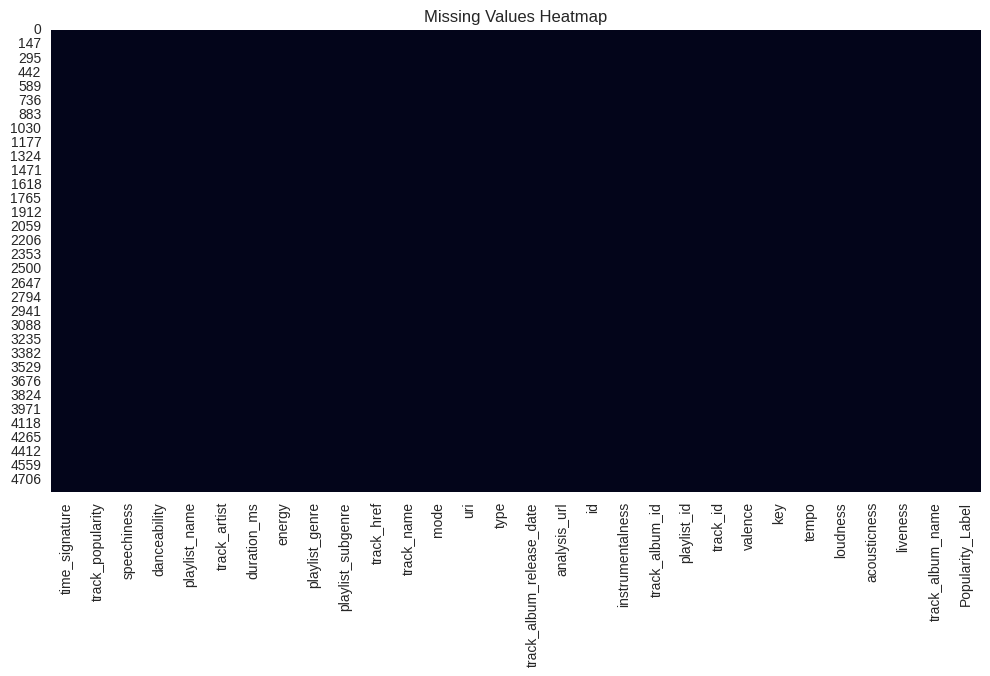

In [7]:
# Visualize missing values using a heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df_cleaned.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()

In [8]:
# Drop columns with more than 50% missing values (if any)
threshold = 0.5
df_cleaned = df_cleaned.loc[:, df_cleaned.isnull().mean() < threshold]

# Impute missing numerical values with median
numerical_features = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()
for feature in numerical_features:
    df_cleaned[feature].fillna(df_cleaned[feature].median(), inplace=True)

# Impute missing categorical values with mode
categorical_features = df.select_dtypes(include=[object]).columns.tolist()
for feature in categorical_features:
    df[feature].fillna(df[feature].mode()[0], inplace=True)

## 3.3 Data Type Conversion

In [9]:
# Convert 'track_album_release_date' to datetime
df_cleaned['track_album_release_date'] = pd.to_datetime(df_cleaned['track_album_release_date'], errors='coerce')

# Extract year, month, and day from 'track_album_release_date'
df_cleaned['Release Year'] = df_cleaned['track_album_release_date'].dt.year
df_cleaned['Release Month'] = df_cleaned['track_album_release_date'].dt.month
df_cleaned['Release Day'] = df_cleaned['track_album_release_date'].dt.day

In [10]:
# Handle missing values in the new date features if necessary
df_cleaned['Release Year'].fillna(df_cleaned['Release Year'].median(), inplace=True)
df_cleaned['Release Month'].fillna(df_cleaned['Release Month'].median(), inplace=True)
df_cleaned['Release Day'].fillna(df_cleaned['Release Day'].median(), inplace=True)

# Convert 'key' and 'mode' to categorical
df_cleaned['key'] = df_cleaned['key'].astype('category')
df_cleaned['mode'] = df_cleaned['mode'].astype('category')

# Update lists of numerical and categorical features
numerical_features = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df_cleaned.select_dtypes(include=['object', 'category']).columns.tolist()

# Exclude non-feature columns
non_feature_columns = [
    'track_name', 'track_artist', 'track_album_name', 'track_id', 'track_album_id',
    'playlist_name', 'playlist_id', 'track_popularity', 'Popularity_Label', 'id', 
    'track_href', 'analysis_url', 'uri', 'type', 'track_album_release_date'
]

# Define features
features = df_cleaned.columns.drop(non_feature_columns, errors='ignore').tolist()

## 3.4 Feature Engineering

In [11]:
# Encoding categorical variables using One-Hot Encoding
categorical_features_to_encode = ['key', 'mode', 'playlist_genre', 'playlist_subgenre']

df_encoded = pd.get_dummies(df_cleaned, columns=categorical_features_to_encode, drop_first=True)

# Update feature list after encoding
features = [feature for feature in df_encoded.columns if feature not in non_feature_columns + ['Popularity_Label', 'Popular']]

# Scaling numerical features
scaler = StandardScaler()
df_encoded[numerical_features] = scaler.fit_transform(df_encoded[numerical_features])

# 4. Exploratory Data Analysis (EDA)

In [12]:
# List of numerical features (excluding the target variable and IDs)
numerical_features = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms',
    'time_signature', 'Release Year', 'Release Month', 'Release Day'
]

# Display summary statistics
df_cleaned[numerical_features].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
danceability,4829.0,0.622299,0.187723,0.058900,0.5250,0.653000,0.758,0.979
energy,4829.0,0.586621,0.246240,0.000202,0.4420,0.633000,0.777,0.998
loudness,4829.0,-9.283028,7.129469,-48.069000,-10.2980,-7.191000,-5.339,1.318
speechiness,4829.0,0.101747,0.101040,0.021900,0.0386,0.056100,0.118,0.927
acousticness,4829.0,0.341279,0.325387,0.000004,0.0530,0.225000,0.590,0.996
instrumentalness,4829.0,0.201094,0.351943,0.000000,0.0000,0.000092,0.201,0.991
liveness,4829.0,0.167609,0.124442,0.021000,0.0954,0.118000,0.195,0.979
valence,4829.0,0.481851,0.258006,0.029600,0.2750,0.483000,0.690,0.987
tempo,4829.0,118.271840,28.515018,48.232000,96.0630,118.068000,136.732,241.426
duration_ms,4829.0,206159.787119,81751.643888,35375.000000,159000.0000,194880.000000,233478.000,1355260.000


## 4.1.2 Summary Statistics for Categorical Features

In [13]:
# List of categorical features
categorical_features = ['key', 'mode', 'playlist_genre', 'playlist_subgenre']

# Display count of unique values and top frequencies
df_cleaned[categorical_features].describe().transpose()

,count,unique,top,freq
key,4829.0,12.0,1.0,587.0
mode,4829.0,2.0,1.0,2715.0
playlist_genre,4829,35,electronic,589
playlist_subgenre,4829,84,modern,694


## 4.2 Distribution Analysis

Let's visualize the distribution of numerical features and analyze differences between low and high-popularity songs.

### 4.2.1 Histograms for Numerical Features

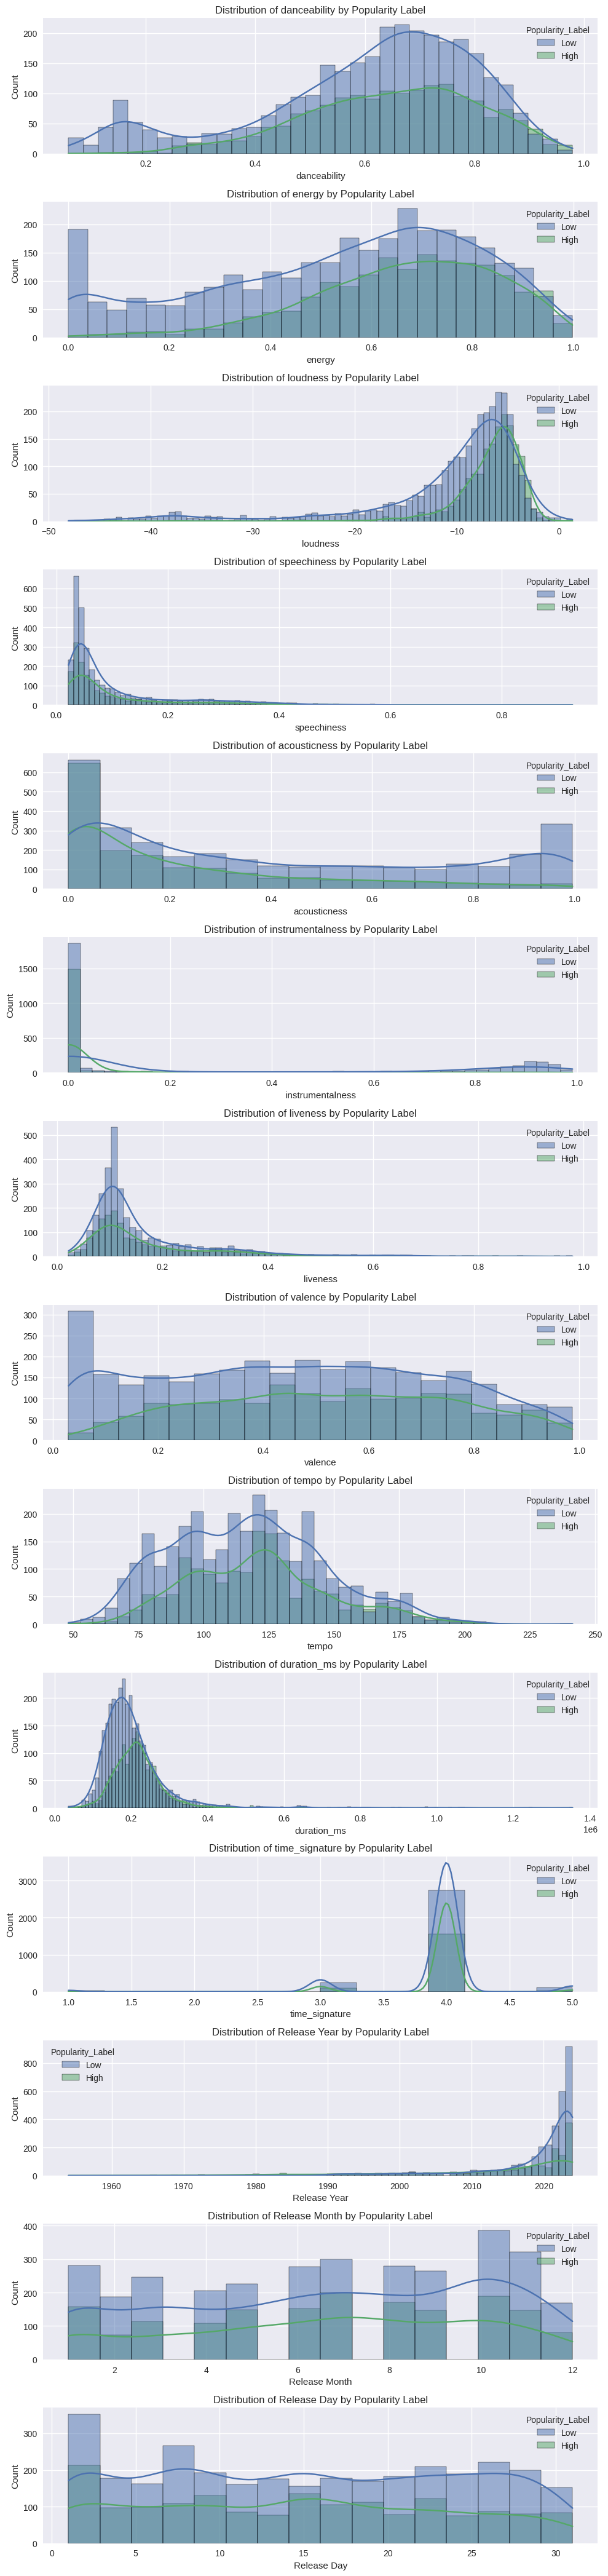

In [14]:
# Set up the matplotlib figure
fig, axes = plt.subplots(len(numerical_features), 1, figsize=(10, len(numerical_features)*3))

# Plot histograms
for idx, feature in enumerate(numerical_features):
    sns.histplot(data=df_cleaned, x=feature, hue='Popularity_Label', kde=True, ax=axes[idx])
    axes[idx].set_title(f'Distribution of {feature} by Popularity Label')

plt.tight_layout()
plt.show()

### 4.2.2 Boxplots for Numerical Features

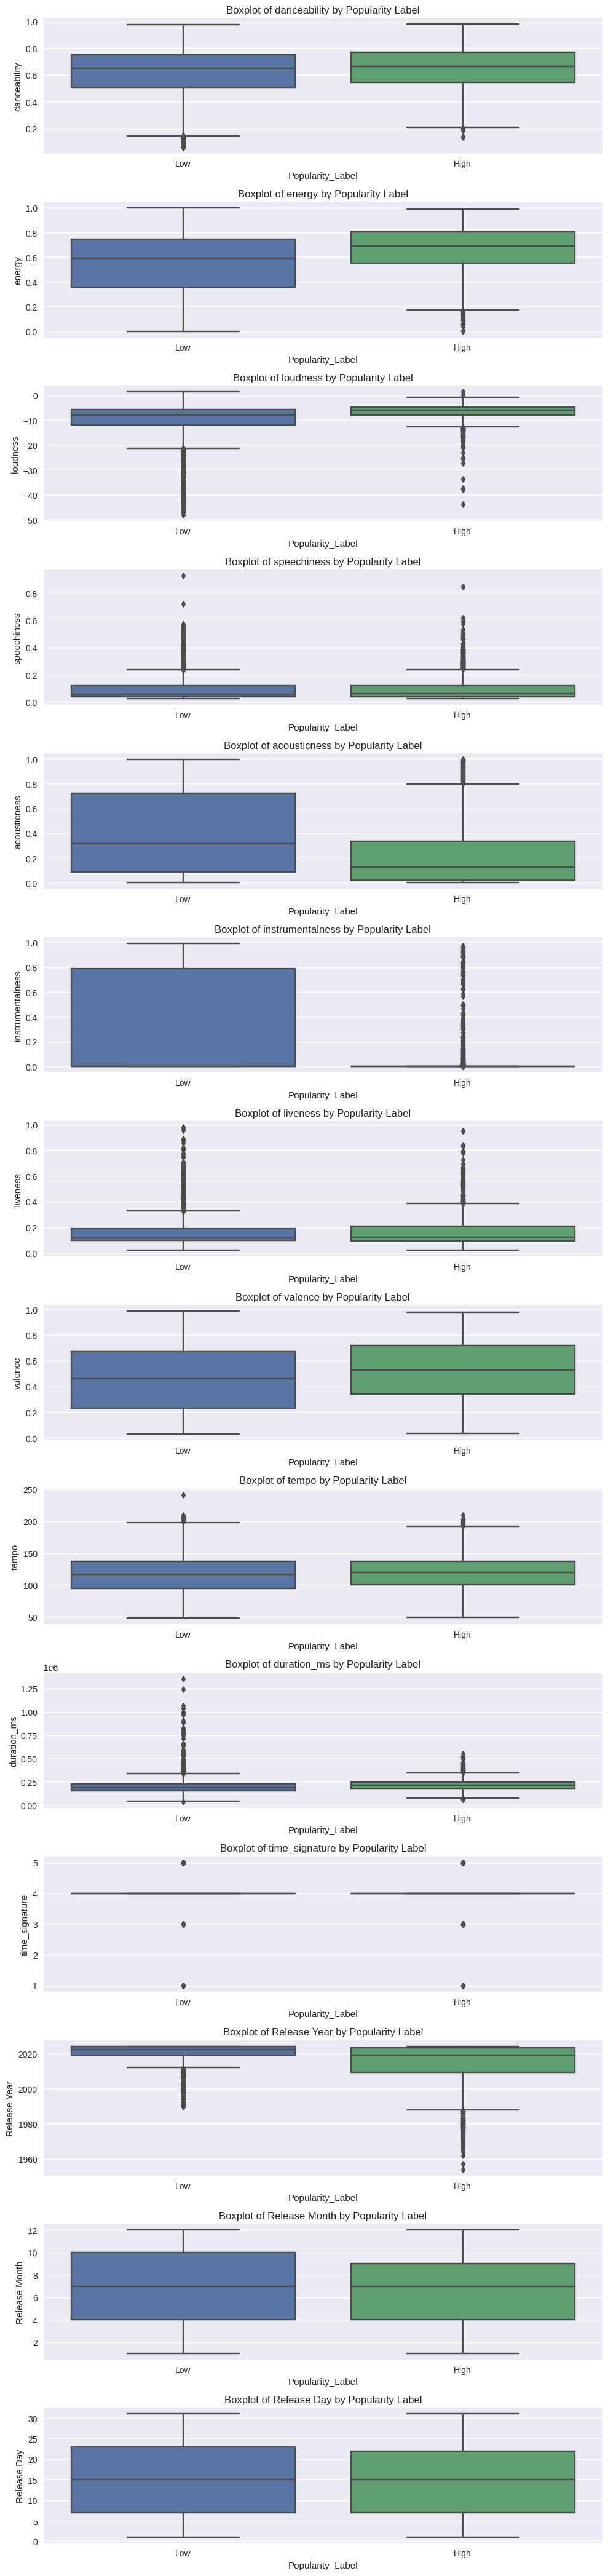

In [15]:
# Set up the matplotlib figure
fig, axes = plt.subplots(len(numerical_features), 1, figsize=(10, len(numerical_features)*3))

# Plot boxplots
for idx, feature in enumerate(numerical_features):
    sns.boxplot(data=df_cleaned, x='Popularity_Label', y=feature, ax=axes[idx])
    axes[idx].set_title(f'Boxplot of {feature} by Popularity Label')

plt.tight_layout()
plt.show()

### 4.2.3 Correlation Matrix

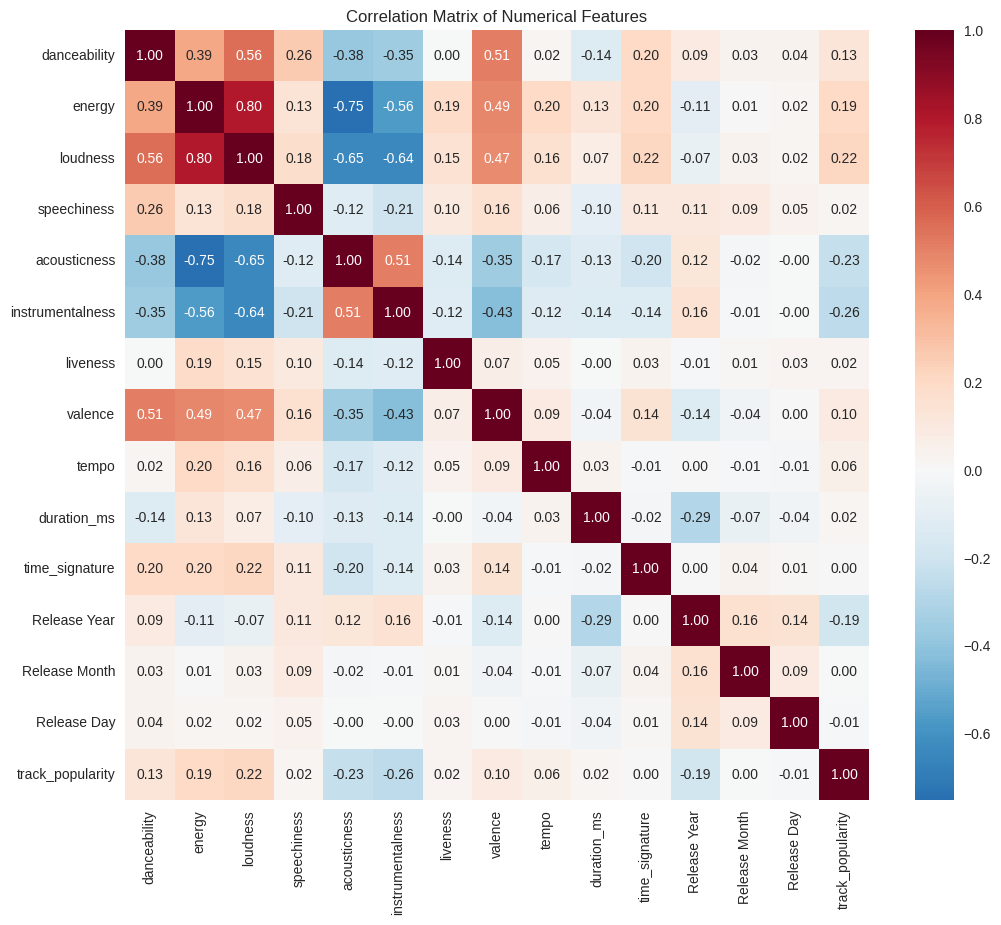

In [16]:
# Compute the correlation matrix
corr_matrix = df_cleaned[numerical_features + ['track_popularity']].corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## 4.3 Analysis of Categorical Features
### 4.3.1 Count Plots for Categorical Features

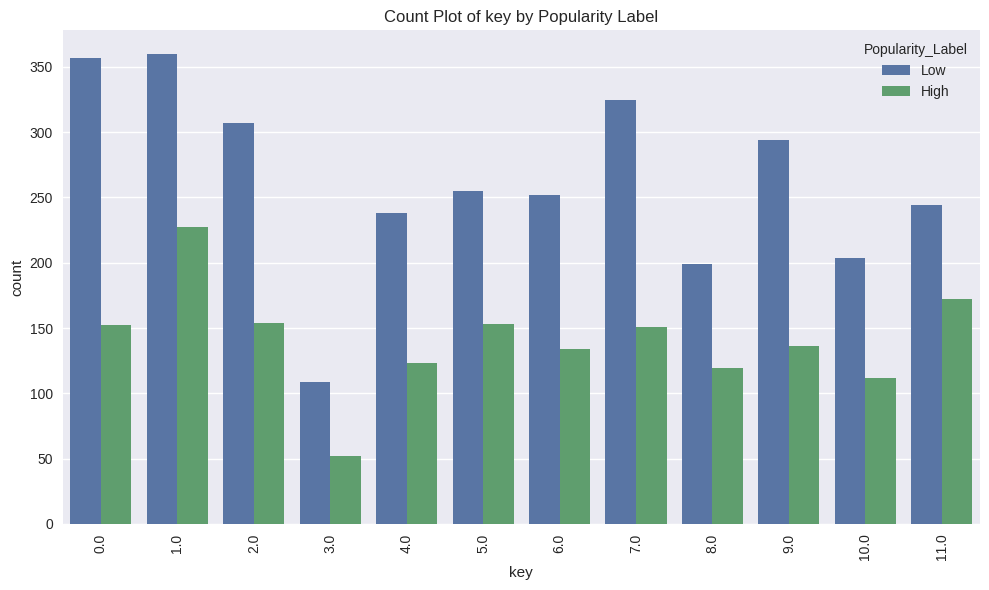

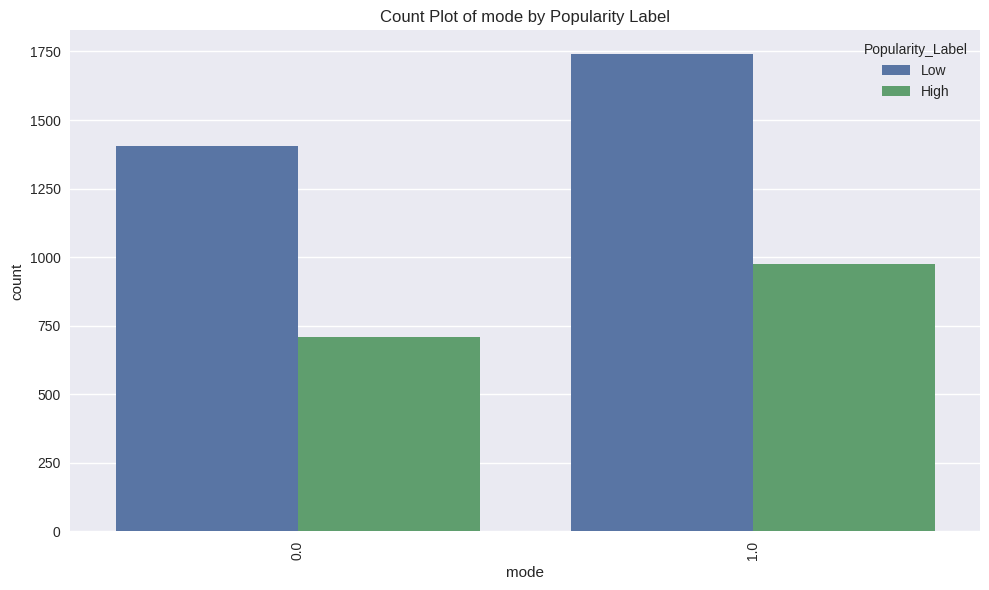

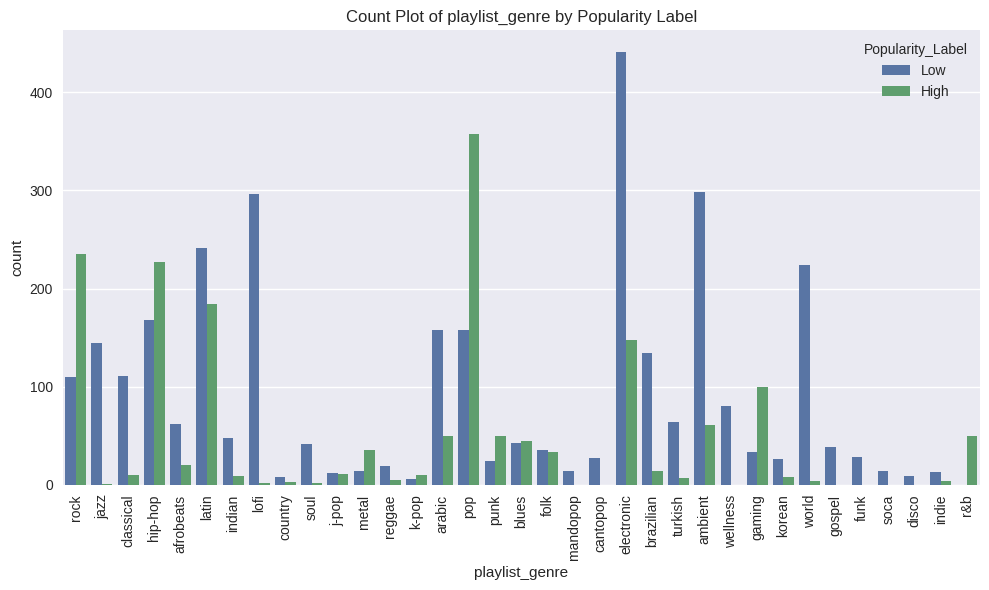

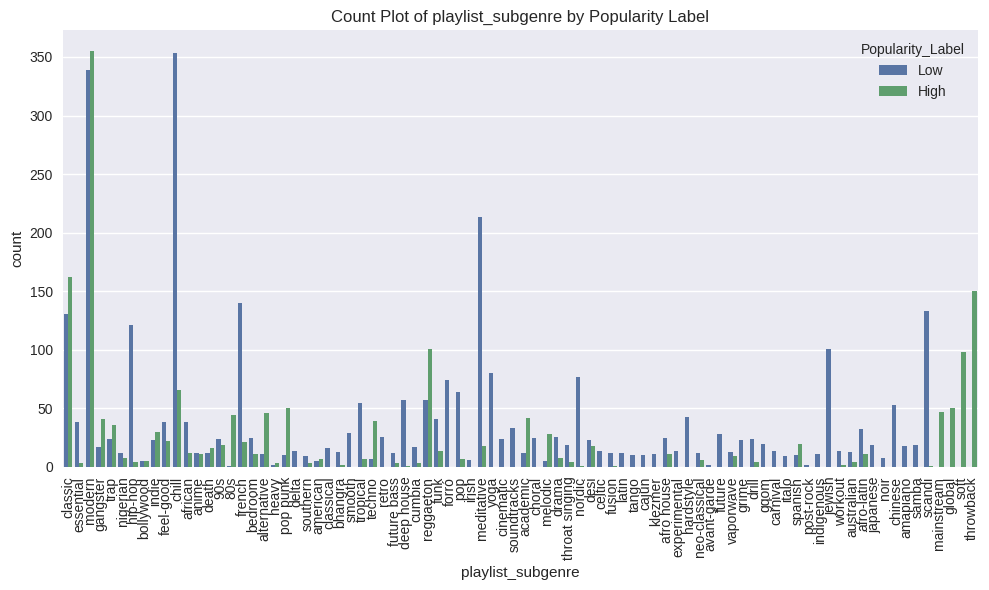

In [17]:
# Plot count plots for each categorical feature
for feature in categorical_features:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_cleaned, x=feature, hue='Popularity_Label')
    plt.title(f'Count Plot of {feature} by Popularity Label')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

## 4.4 Feature Relationships with Popularity
### 4.4.1 Scatter Plots

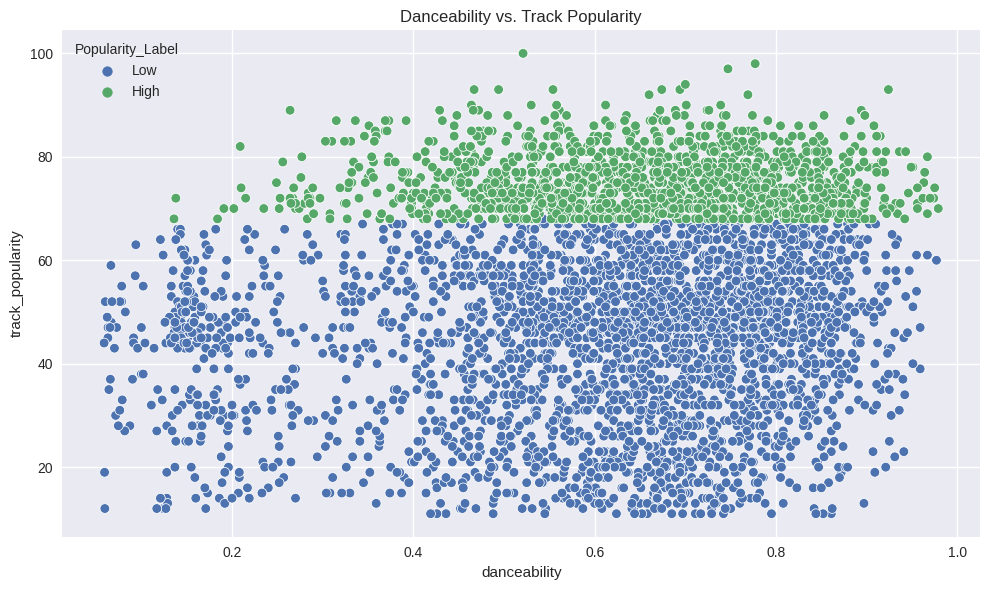

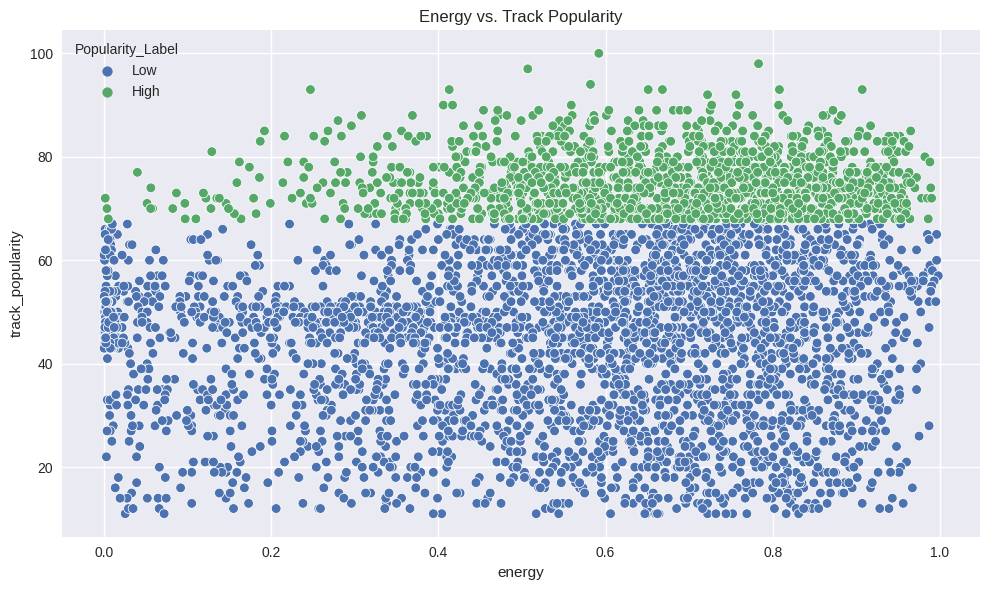

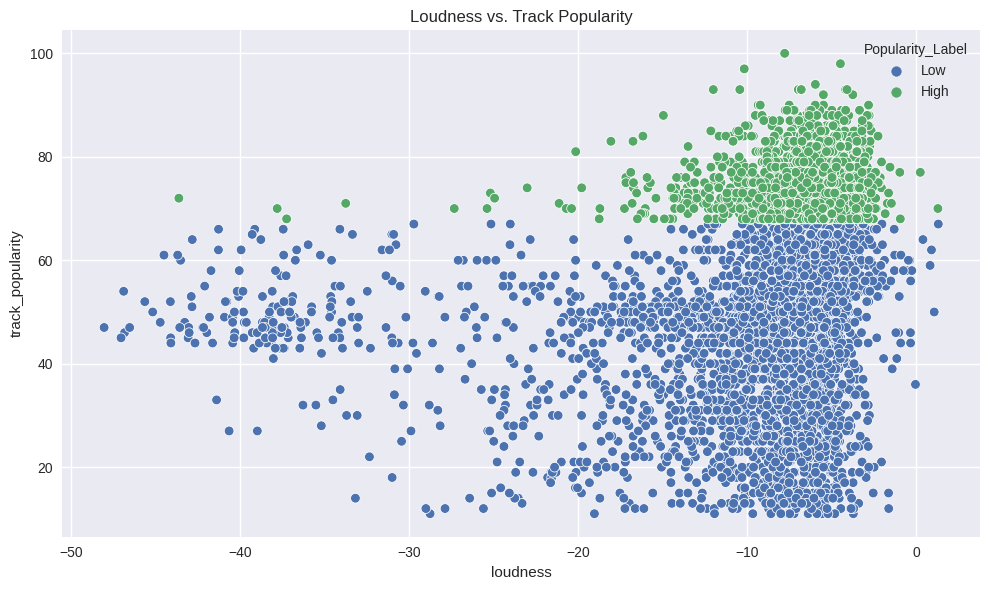

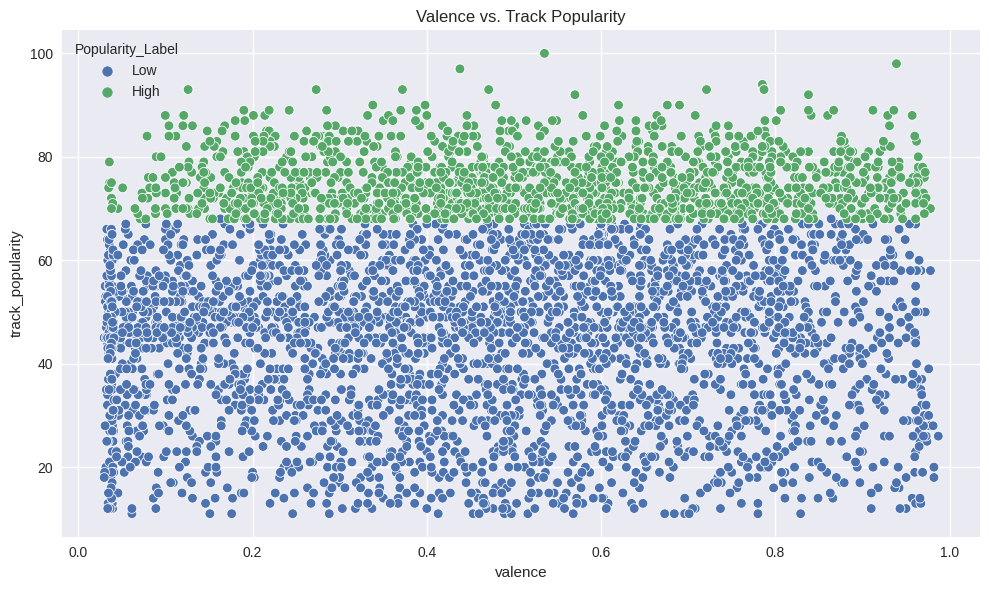

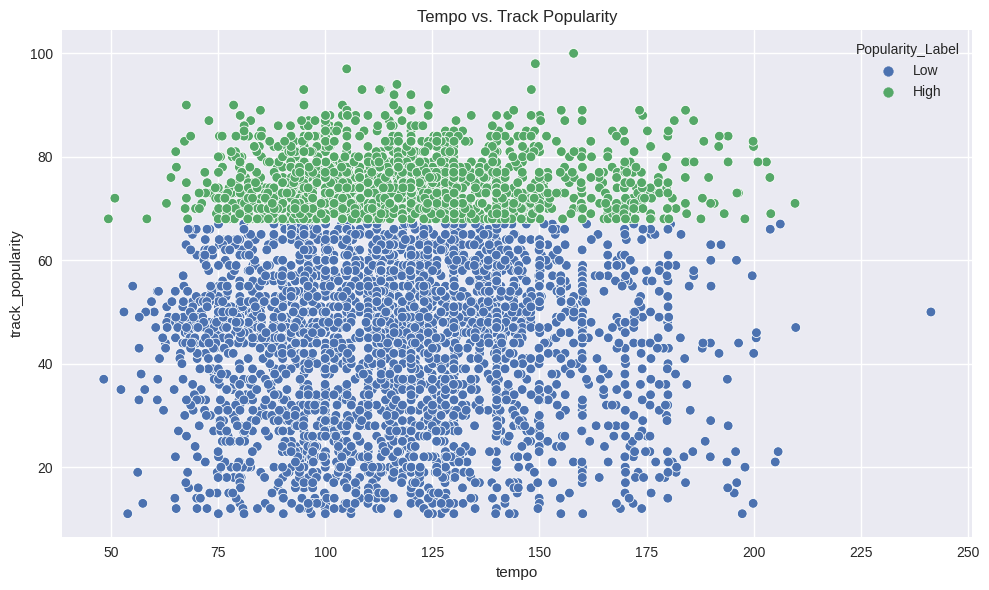

In [18]:
# Define a list of features to plot against popularity
features_to_plot = ['danceability', 'energy', 'loudness', 'valence', 'tempo']

# Plot scatter plots
for feature in features_to_plot:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_cleaned, x=feature, y='track_popularity', hue='Popularity_Label')
    plt.title(f'{feature.capitalize()} vs. Track Popularity')
    plt.tight_layout()
    plt.show()

### 4.4.2 Violin Plots


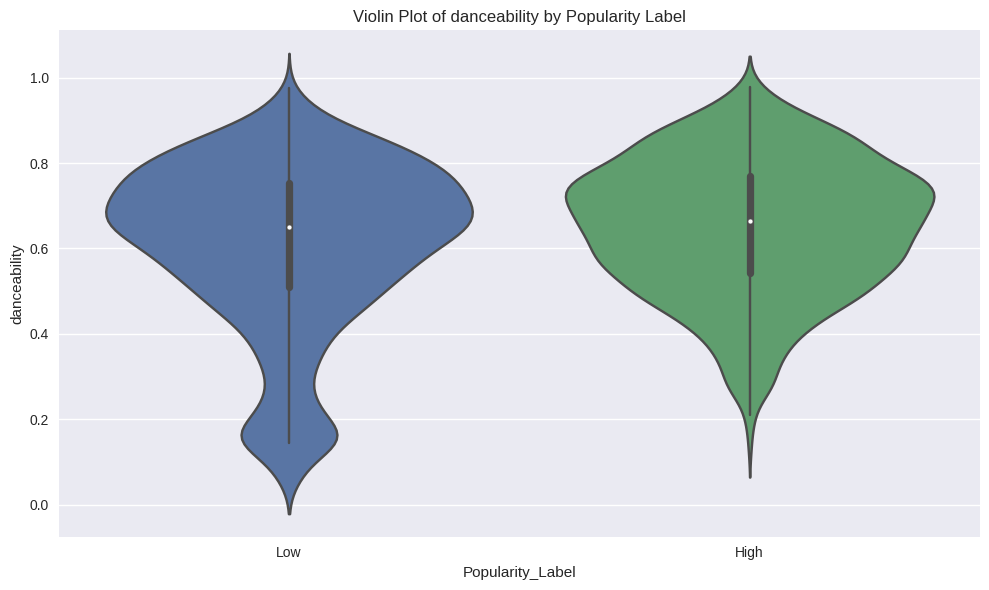

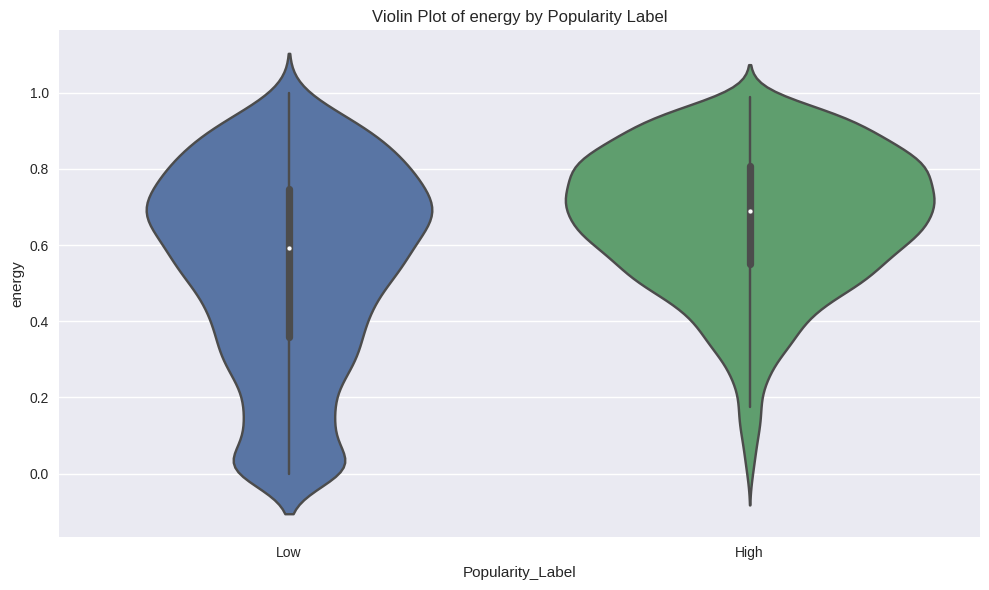

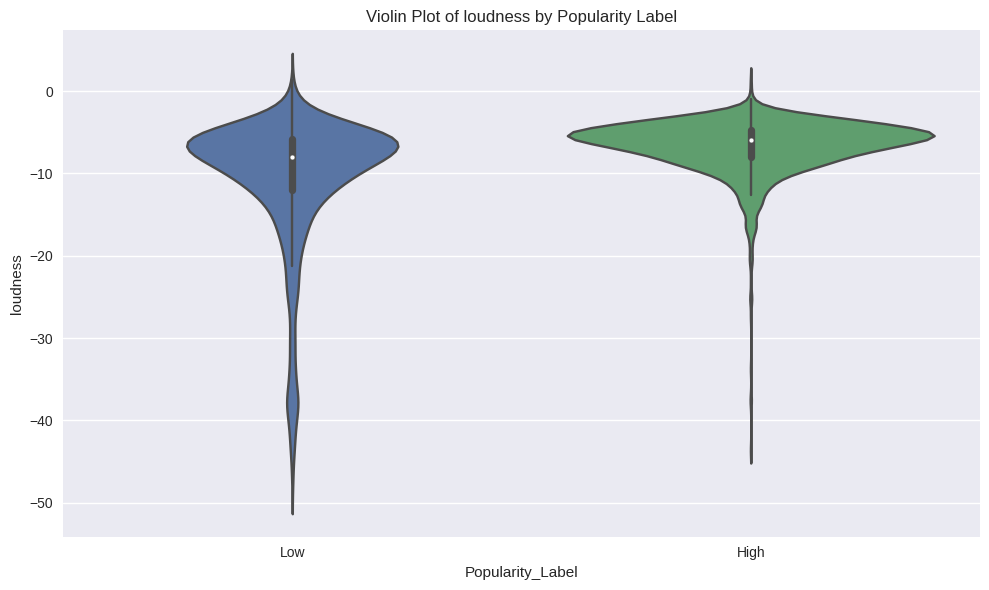

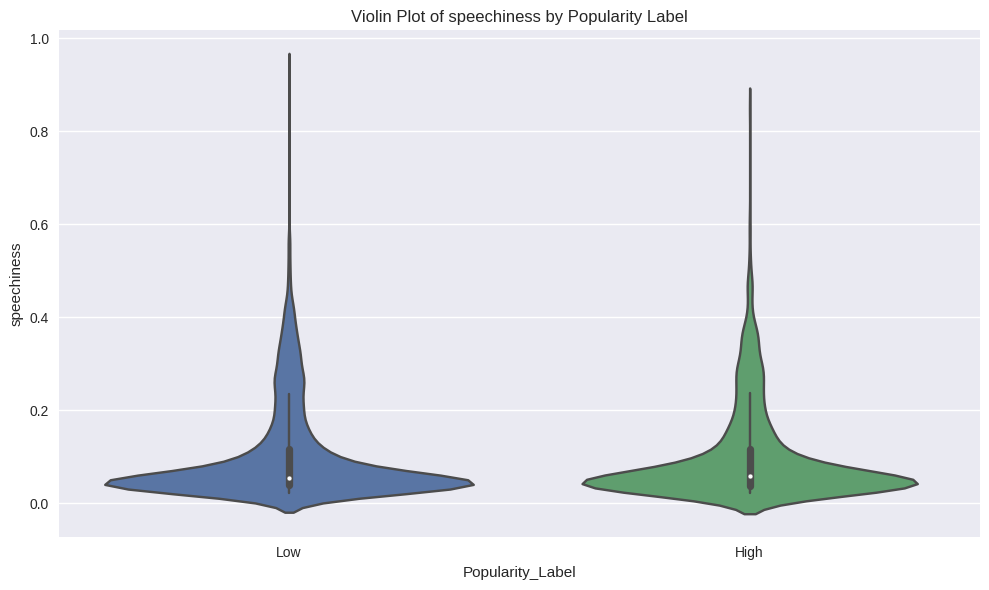

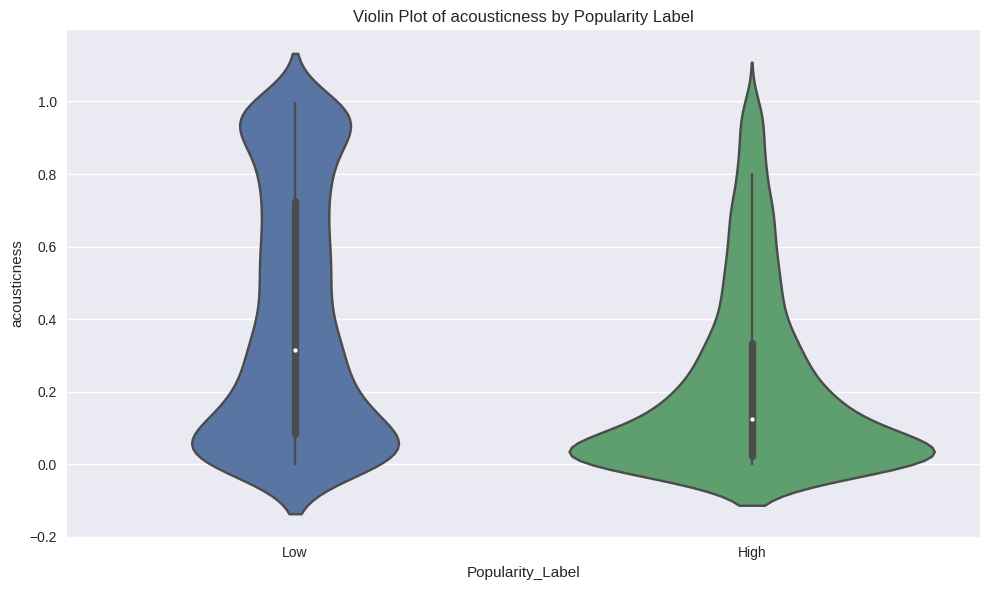

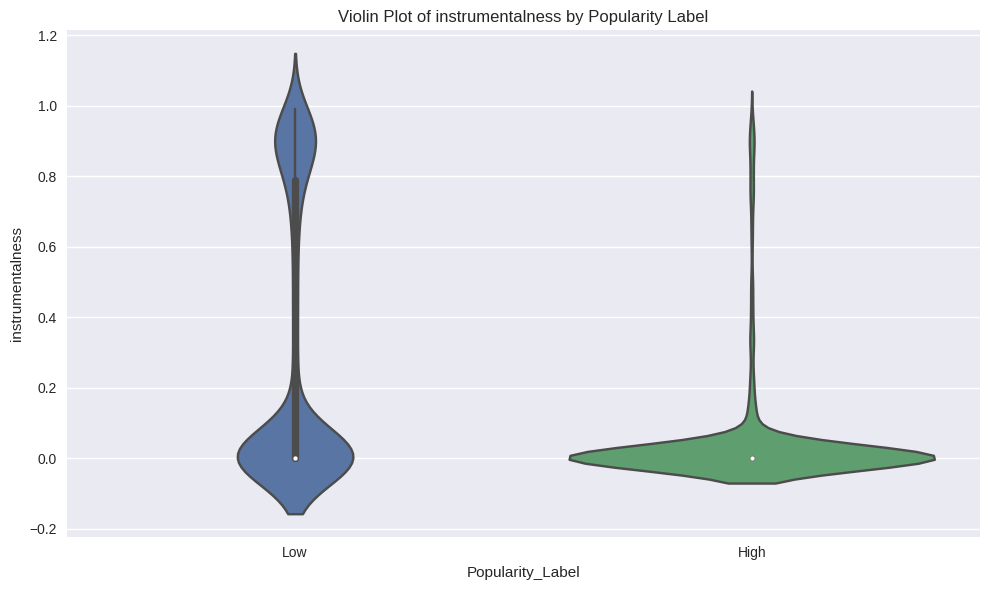

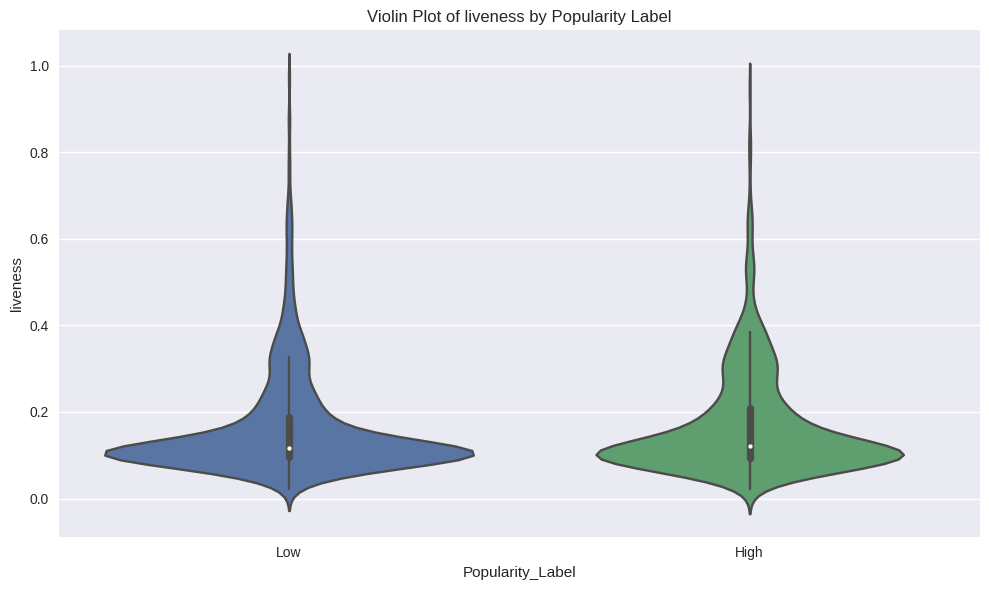

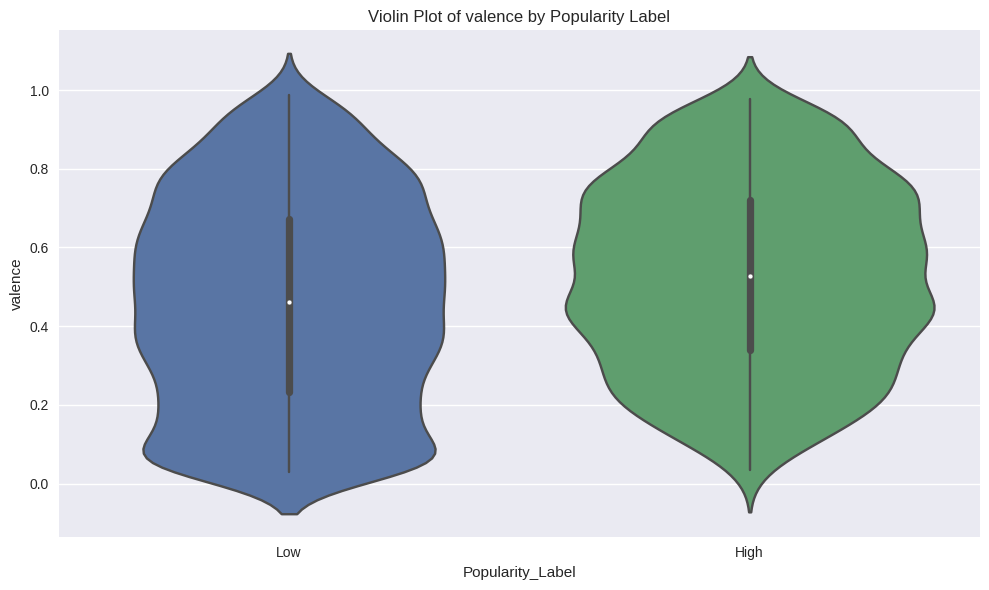

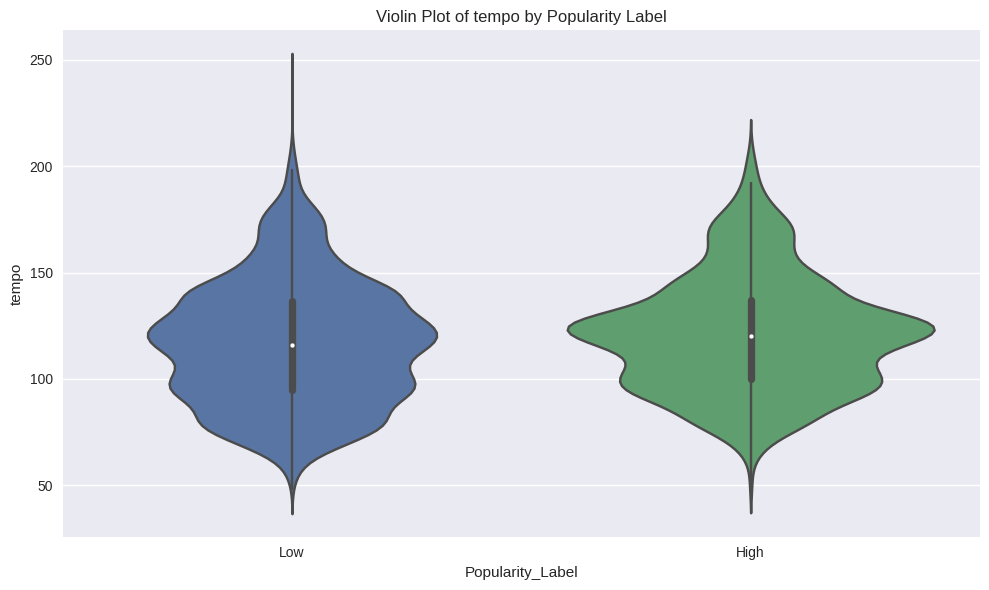

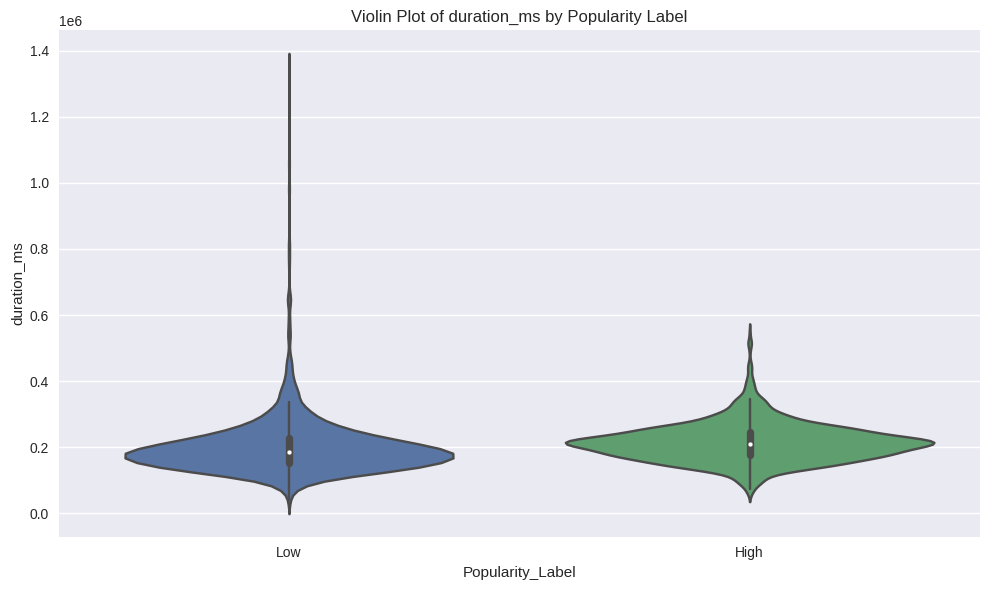

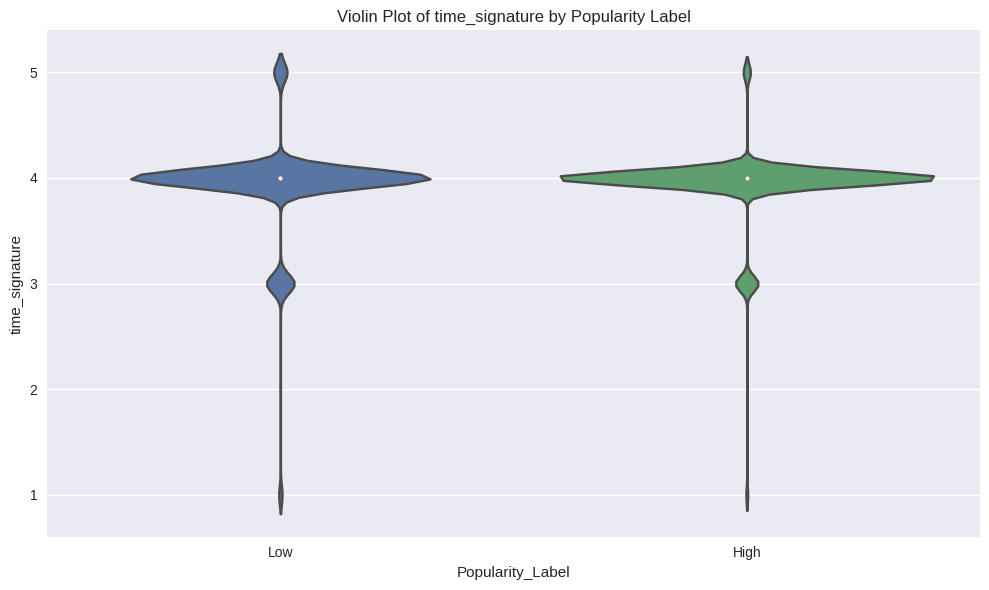

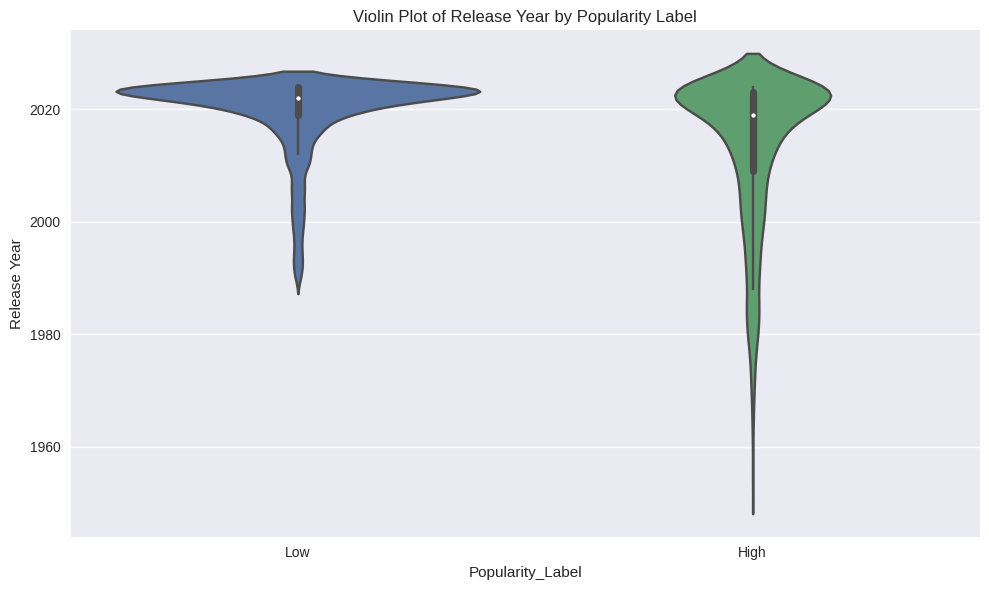

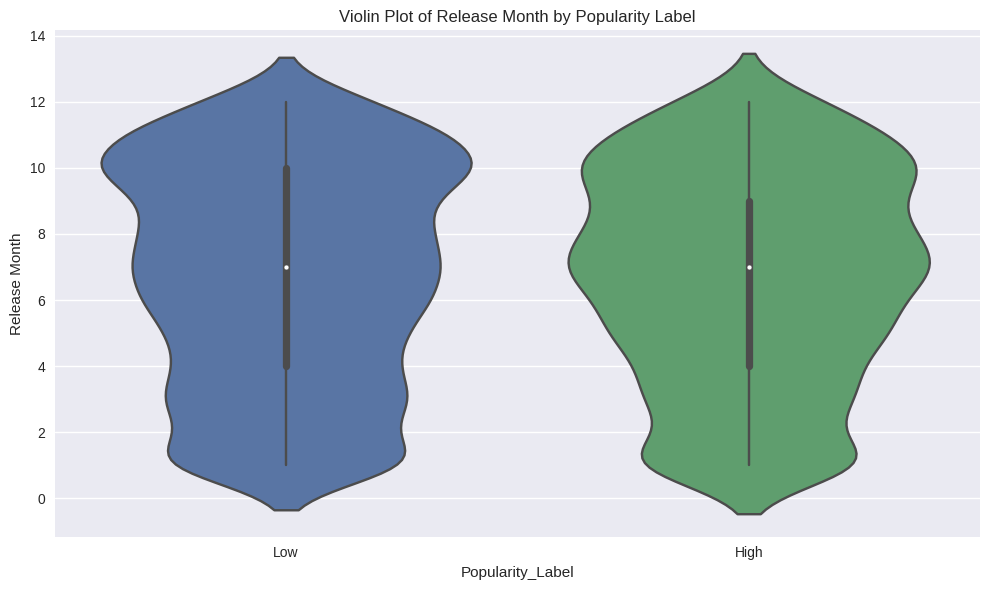

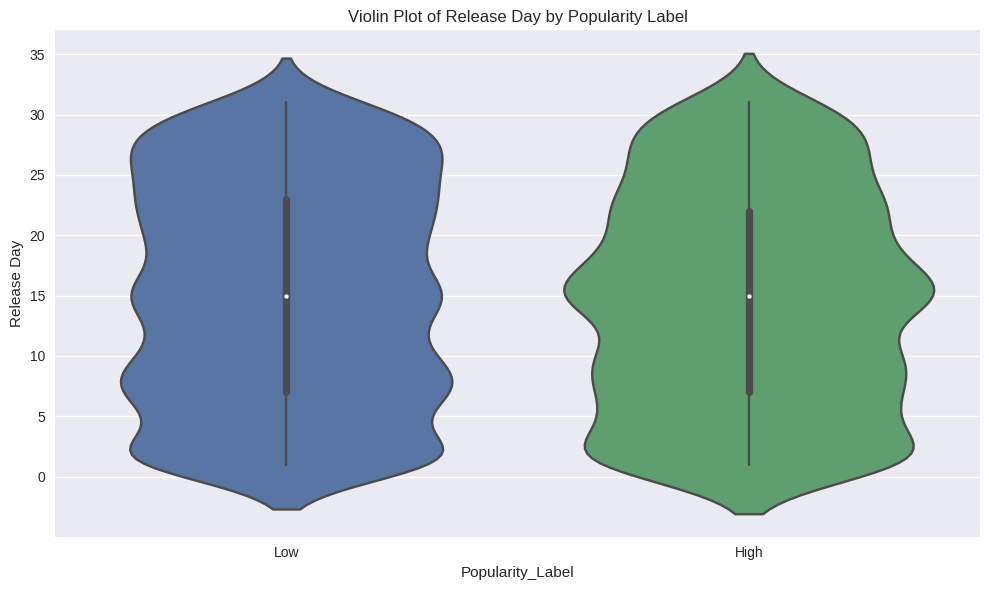

In [19]:
# Plot violin plots to show the distribution of features
for feature in numerical_features:
    plt.figure(figsize=(10, 6))
    sns.violinplot(data=df_cleaned, x='Popularity_Label', y=feature)
    plt.title(f'Violin Plot of {feature} by Popularity Label')
    plt.tight_layout()
    plt.show()

### 4.4.3 Pair Plot

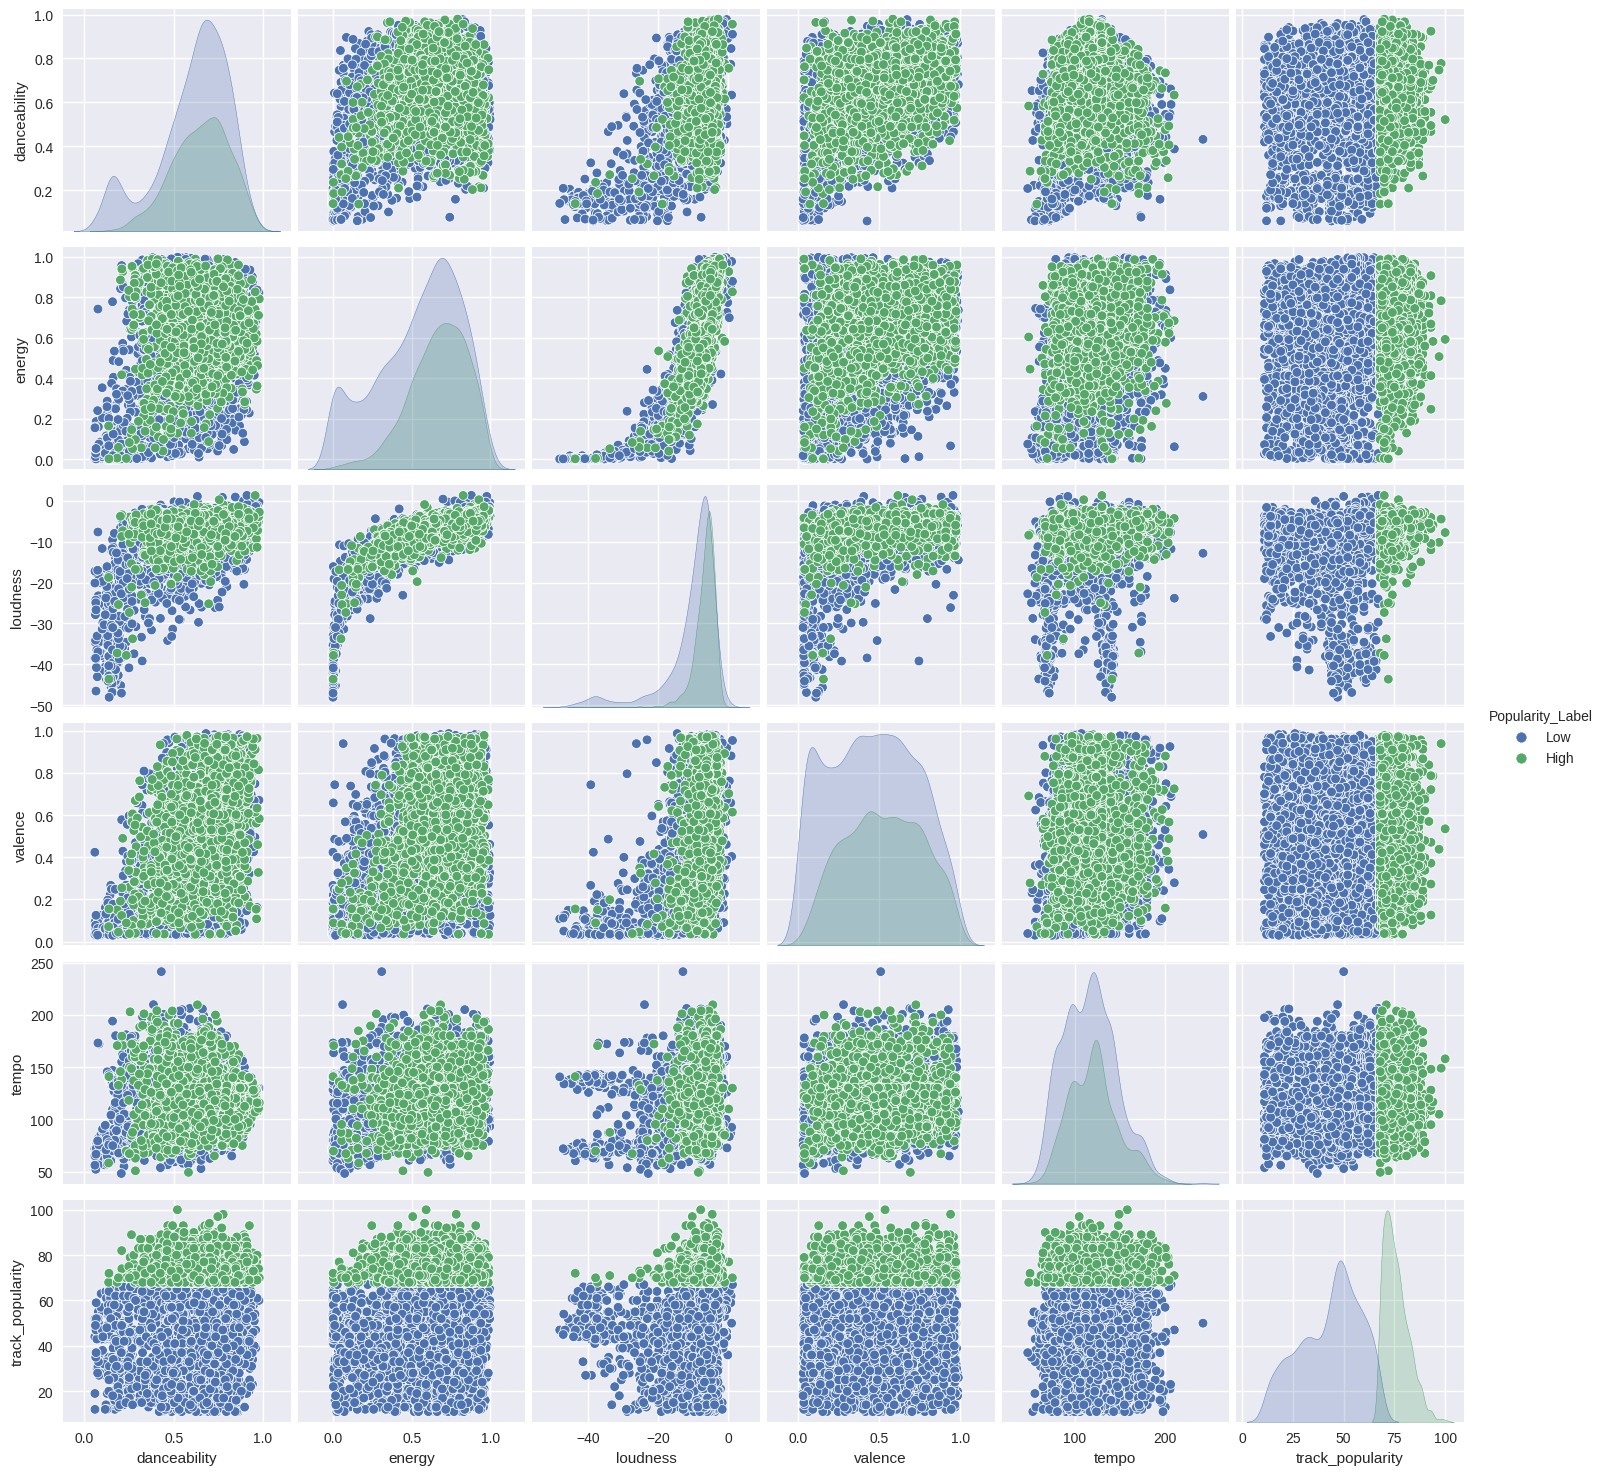

In [20]:
# Select a subset of features to include in the pair plot to avoid clutter
selected_features = ['danceability', 'energy', 'loudness', 'valence', 'tempo', 'track_popularity']

# Create a pair plot
sns.pairplot(df_cleaned[selected_features + ['Popularity_Label']], hue='Popularity_Label')
plt.show()

## 4.5 Statistical Tests
### 4.5.1 T-Tests Between Low and High-Popularity Songs

We'll perform t-tests to determine if the difference in means of features between low and high-popularity songs is statistically significant.

In [21]:
from scipy.stats import ttest_ind

# Separate the dataframe into low and high popularity songs
df_low_pop = df_cleaned[df_cleaned['Popularity_Label'] == 'Low']
df_high_pop = df_cleaned[df_cleaned['Popularity_Label'] == 'High']

# Perform t-tests for numerical features
significant_features = []
alpha = 0.05  # Significance level

for feature in numerical_features:
    stat, p = ttest_ind(df_low_pop[feature], df_high_pop[feature], nan_policy='omit')
    print(f'{feature}: p-value = {p:.4f}')
    if p < alpha:
        significant_features.append(feature)
        print(f'  -> Significant difference in means (p < {alpha})\n')
    else:
        print(f'  -> No significant difference in means (p >= {alpha})\n')

danceability: p-value = 0.0000
  -> Significant difference in means (p < 0.05)

energy: p-value = 0.0000
  -> Significant difference in means (p < 0.05)

loudness: p-value = 0.0000
  -> Significant difference in means (p < 0.05)

speechiness: p-value = 0.6884
  -> No significant difference in means (p >= 0.05)

acousticness: p-value = 0.0000
  -> Significant difference in means (p < 0.05)

instrumentalness: p-value = 0.0000
  -> Significant difference in means (p < 0.05)

liveness: p-value = 0.1056
  -> No significant difference in means (p >= 0.05)

valence: p-value = 0.0000
  -> Significant difference in means (p < 0.05)

tempo: p-value = 0.0000
  -> Significant difference in means (p < 0.05)

duration_ms: p-value = 0.0000
  -> Significant difference in means (p < 0.05)

time_signature: p-value = 0.0933
  -> No significant difference in means (p >= 0.05)

Release Year: p-value = 0.0000
  -> Significant difference in means (p < 0.05)

Release Month: p-value = 0.7065
  -> No significan

## 4.6 Correlation with Target Variable
### 4.6.1 Calculating Correlation with Track Popularity

In [22]:
# Calculate Pearson correlation coefficients between numerical features and track popularity
feature_correlations = df_cleaned[numerical_features + ['track_popularity']].corr()['track_popularity'].sort_values(ascending=False)

# Display the correlations
print('Correlation with Track Popularity:')
print(feature_correlations)

Correlation with Track Popularity:
track_popularity    1.000000
loudness            0.216958
energy              0.194502
danceability        0.128340
valence             0.096567
tempo               0.059954
liveness            0.022226
duration_ms         0.021566
speechiness         0.019330
time_signature      0.003213
Release Month       0.000731
Release Day        -0.006624
Release Year       -0.194514
acousticness       -0.232543
instrumentalness   -0.263070
Name: track_popularity, dtype: float64


### 4.6.2 Visualizing Feature Correlations

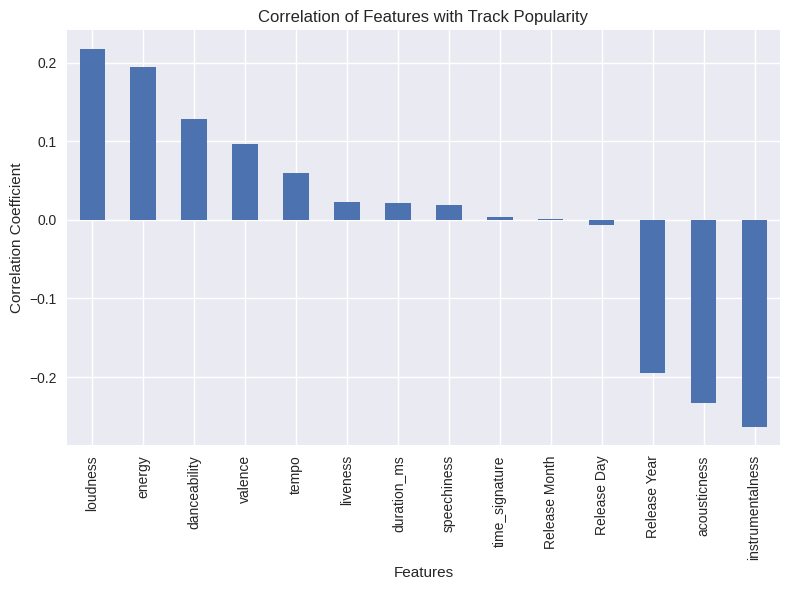

In [23]:
# Plot the correlations
plt.figure(figsize=(8, 6))
feature_correlations.drop('track_popularity').plot(kind='bar')
plt.title('Correlation of Features with Track Popularity')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

## 4.7 Analysis of Release Date Features
### 4.7.1 Popularity Over Release Years

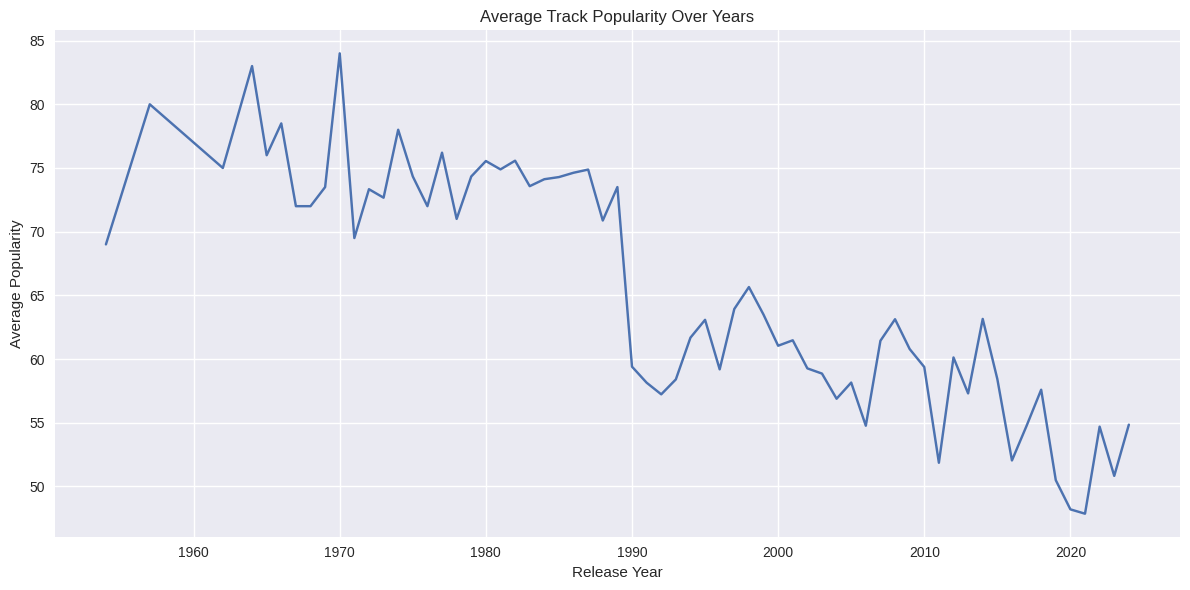

In [24]:
# Average popularity by release year
popularity_by_year = df_cleaned.groupby('Release Year')['track_popularity'].mean()

# Plot the trend
plt.figure(figsize=(12, 6))
popularity_by_year.plot()
plt.title('Average Track Popularity Over Years')
plt.xlabel('Release Year')
plt.ylabel('Average Popularity')
plt.tight_layout()
plt.show()

### 4.7.2 Number of Tracks Released Over Years

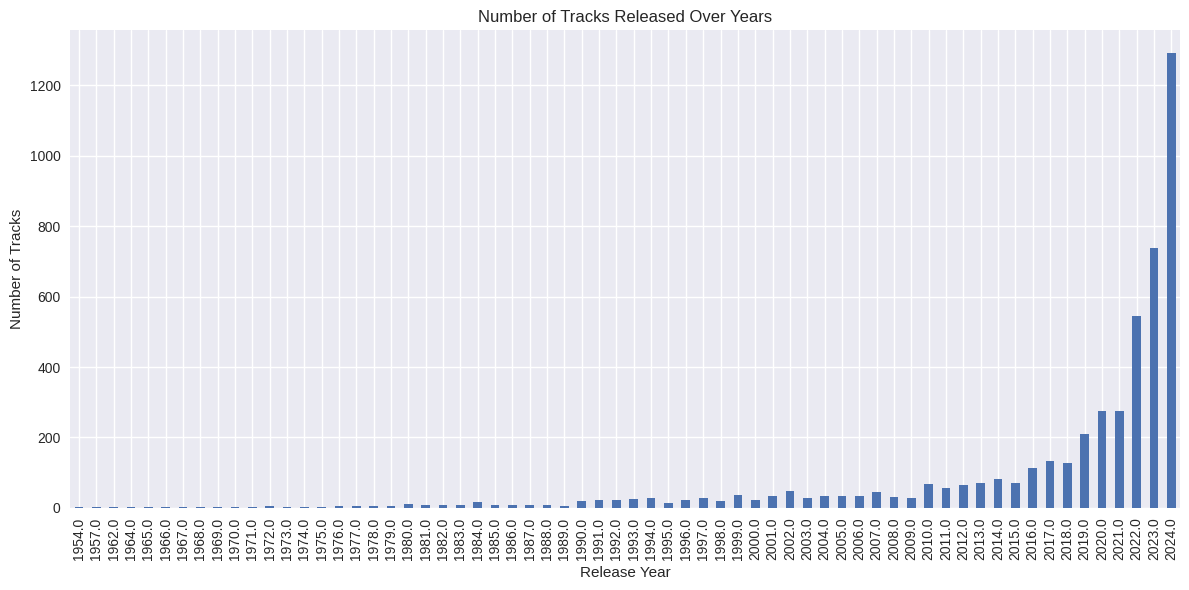

In [25]:
# Count of tracks by release year
tracks_per_year = df_cleaned.groupby('Release Year').size()

# Plot the counts
plt.figure(figsize=(12, 6))
tracks_per_year.plot(kind='bar')
plt.title('Number of Tracks Released Over Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Tracks')
plt.tight_layout()
plt.show()

## 4.8 Categorical Feature Analysis
### 4.8.1 Popularity by Playlist Genre

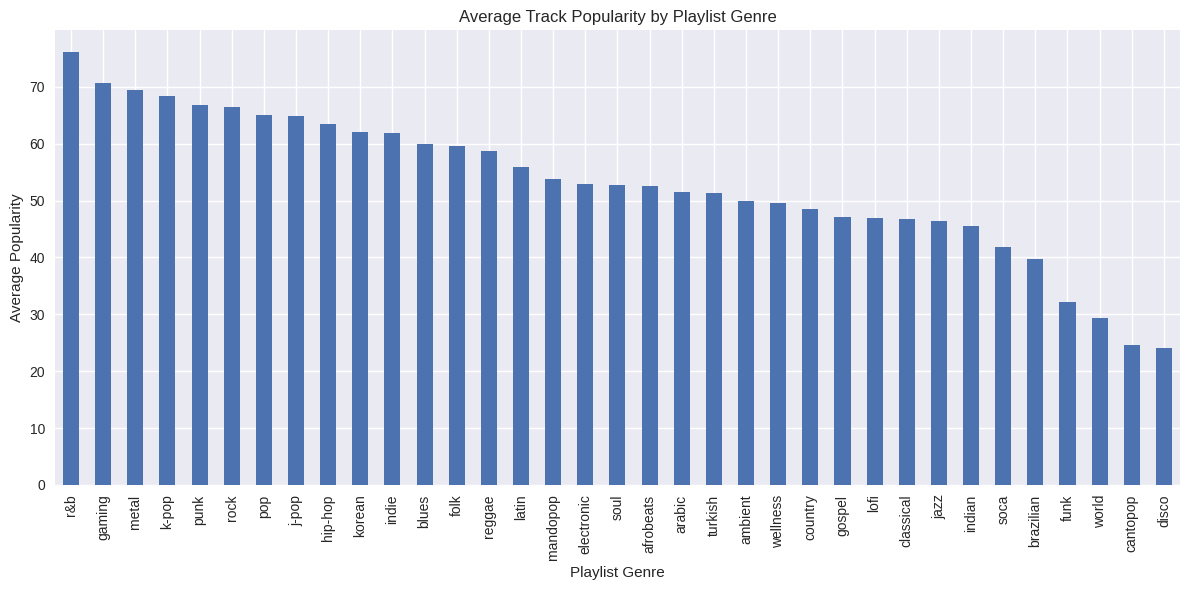

In [26]:
# Average popularity by playlist genre
popularity_by_genre = df_cleaned.groupby('playlist_genre')['track_popularity'].mean().sort_values(ascending=False)

# Plot the top genres
plt.figure(figsize=(12, 6))
popularity_by_genre.plot(kind='bar')
plt.title('Average Track Popularity by Playlist Genre')
plt.xlabel('Playlist Genre')
plt.ylabel('Average Popularity')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 4.8.2 Popularity by Playlist Subgenre

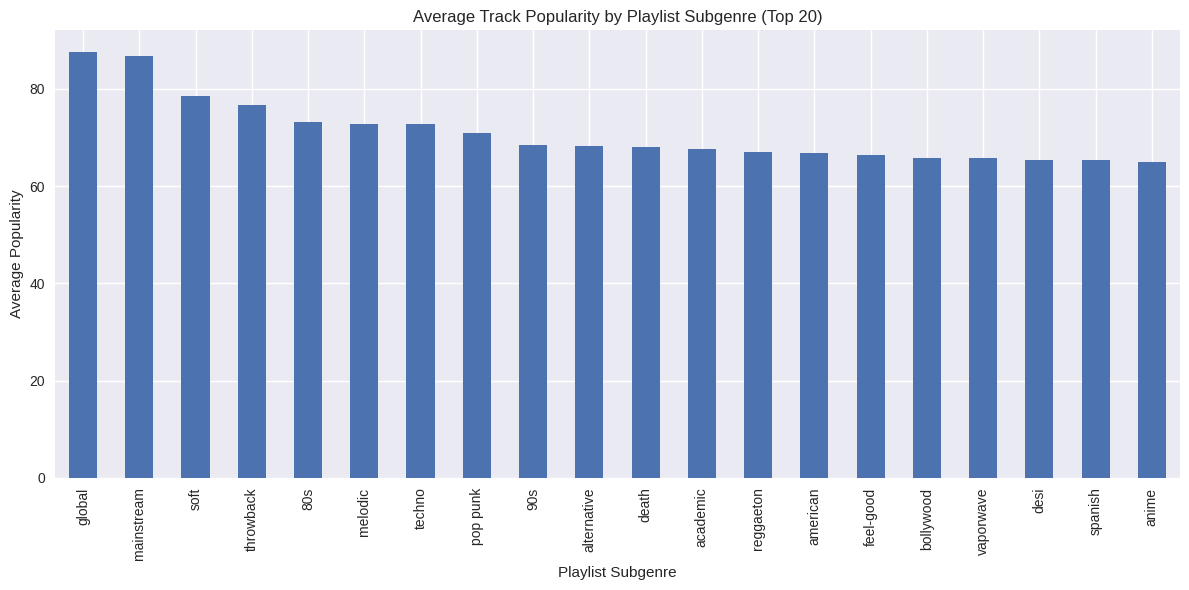

In [27]:
# Average popularity by playlist subgenre
popularity_by_subgenre = df_cleaned.groupby('playlist_subgenre')['track_popularity'].mean().sort_values(ascending=False)

# Plot the top subgenres
plt.figure(figsize=(12, 6))
popularity_by_subgenre.head(20).plot(kind='bar')
plt.title('Average Track Popularity by Playlist Subgenre (Top 20)')
plt.xlabel('Playlist Subgenre')
plt.ylabel('Average Popularity')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 4.8.3 Mode and Key Distribution

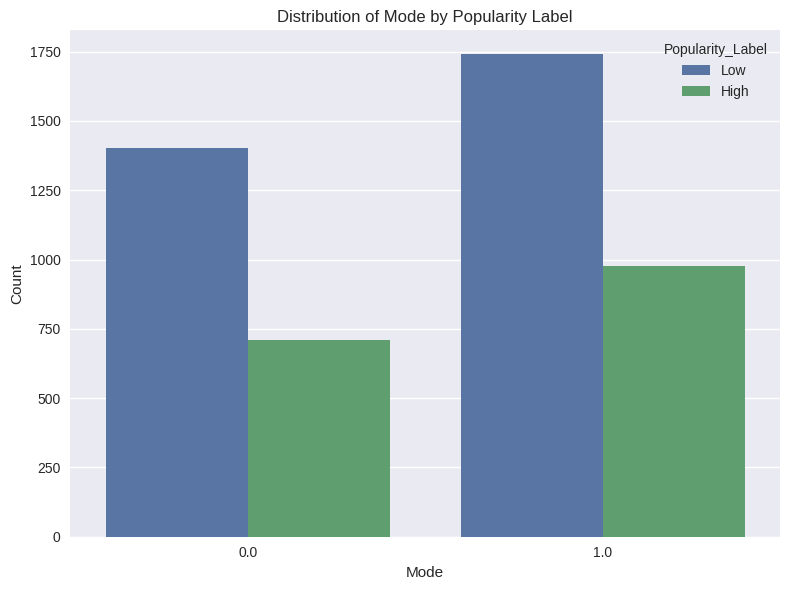

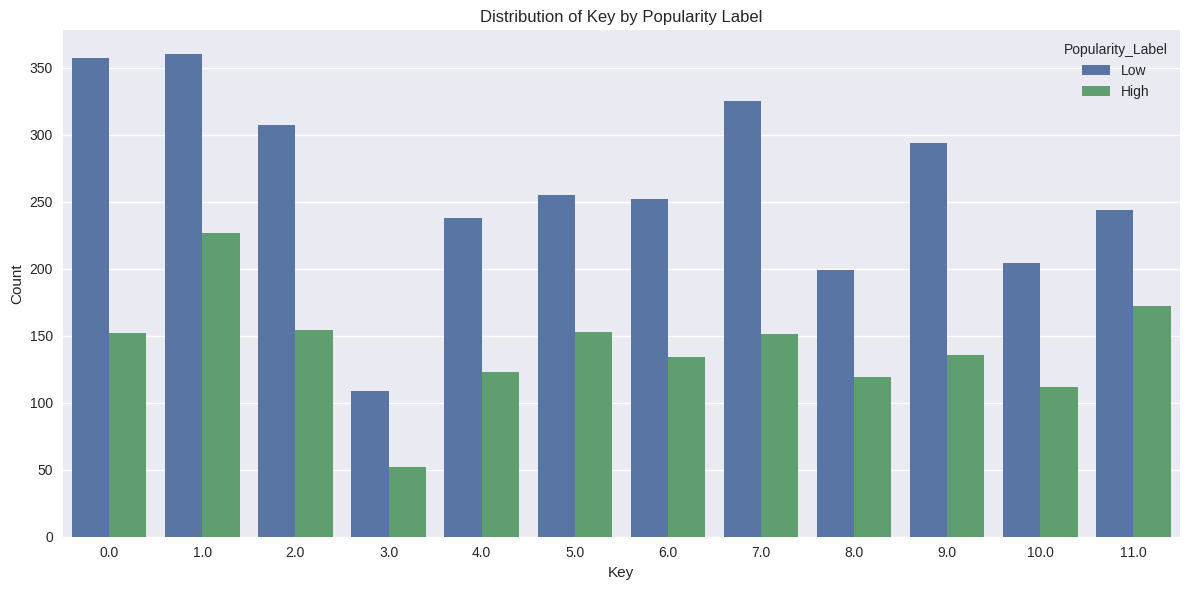

In [28]:
# Mode distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=df_cleaned, x='mode', hue='Popularity_Label')
plt.title('Distribution of Mode by Popularity Label')
plt.xlabel('Mode')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Key distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=df_cleaned, x='key', hue='Popularity_Label')
plt.title('Distribution of Key by Popularity Label')
plt.xlabel('Key')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 5. Feature Engineering
### 5.1 Handling Skewed Features

Some features might be skewed. We can apply transformations if necessary.

In [29]:
# Check skewness
skewed_features = df_cleaned[numerical_features].skew().sort_values(ascending=False)
print('Skewness of Numerical Features:')
print(skewed_features)

Skewness of Numerical Features:
duration_ms         3.985025
liveness            2.356692
speechiness         2.057018
instrumentalness    1.349644
acousticness        0.703483
tempo               0.356420
Release Day         0.058877
valence            -0.002808
Release Month      -0.201043
energy             -0.688888
danceability       -0.835852
Release Year       -2.282122
loudness           -2.682891
time_signature     -3.128418
dtype: float64


### 5.1.1 Log Transformation of Highly Skewed Features

In [30]:
# Identify features with high skewness
high_skewness = skewed_features[abs(skewed_features) > 0.5].index.tolist()

# Apply log transformation to positively skewed features
for feature in high_skewness:
    if (df_cleaned[feature] > 0).all():
        df_cleaned[feature] = np.log1p(df_cleaned[feature])

## 5.3 Updating Feature Lists

In [31]:
# Recalculate numerical features if any transformations changed data types
numerical_features = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()

# Remove target variables and IDs from features
non_feature_columns = [
    'track_name', 'track_artist', 'track_album_name', 'track_id', 'track_album_id',
    'playlist_name', 'playlist_id', 'track_popularity', 'Popularity_Label', 'Popular',
    'id', 'track_href', 'analysis_url', 'uri', 'type', 'track_album_release_date'
]

features = [feature for feature in df_cleaned.columns if feature not in non_feature_columns]

## 5.4 Encoding Categorical Variables
### 5.4.1 Identifying Categorical Variables
First, let's identify the categorical variables that need to be encoded.



In [32]:
# List of categorical features to encode
categorical_features = ['key', 'mode', 'playlist_genre', 'playlist_subgenre']

### 5.4.2 Encoding Using One-Hot Encoding
We'll use One-Hot Encoding to convert categorical variables into a format that can be provided to ML algorithms.

In [33]:
# Perform One-Hot Encoding on categorical features
df_encoded = pd.get_dummies(df_cleaned, columns=categorical_features, drop_first=True)

# Display the first few rows of the encoded DataFrame
df_encoded.head()

,time_signature,track_popularity,speechiness,danceability,playlist_name,track_artist,duration_ms,energy,track_href,track_name,...,playlist_subgenre_spanish,playlist_subgenre_tango,playlist_subgenre_techno,playlist_subgenre_throat singing,playlist_subgenre_throwback,playlist_subgenre_trap,playlist_subgenre_tropical,playlist_subgenre_vaporwave,playlist_subgenre_workout,playlist_subgenre_yoga
0,1.609438,23,0.038547,0.492254,Rock Classics,Creedence Clearwater Revival,11.835400,0.557327,https://api.spotify.com/v1/tracks/5e6x5YRnMJIK...,Fortunate Son,...,False,False,False,False,False,False,False,False,False,False
1,1.609438,53,0.031208,0.452349,Rock Classics,Van Halen,12.395043,0.607044,https://api.spotify.com/v1/tracks/5FqYA8KfiwsQ...,Jump - 2015 Remaster,...,False,False,False,False,False,False,False,False,False,False
2,1.609438,55,0.044400,0.464363,Rock Classics,Stevie Nicks,12.705071,0.590006,https://api.spotify.com/v1/tracks/5LNiqEqpDc8T...,Edge of Seventeen - 2016 Remaster,...,False,False,False,False,False,False,False,False,False,False
3,1.609438,64,0.096219,0.366724,Jazz Classics,"Ella Fitzgerald, Louis Armstrong",12.128981,0.098940,https://api.spotify.com/v1/tracks/78MI7mu1LV1k...,Dream A Little Dream Of Me - Single Version,...,False,False,False,False,False,False,False,False,False,False
4,1.609438,62,0.029365,0.521766,Jazz Classics,Galt MacDermot,12.234276,0.386622,https://api.spotify.com/v1/tracks/6MN6yRVriszu...,Coffee Cold,...,False,False,False,False,False,False,False,False,False,False


## 5.5 Scaling Numerical Features
### 5.5.1 Identifying Numerical Features

In [34]:
# List of numerical features
numerical_features = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms',
    'time_signature', 'Release Year', 'Release Month', 'Release Day'
]

### 5.5.2 Scaling Using StandardScaler


In [35]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler to the numerical features
df_encoded[numerical_features] = scaler.fit_transform(df_encoded[numerical_features])

# Display the first few rows of the scaled DataFrame
df_encoded.head()

,time_signature,track_popularity,speechiness,danceability,playlist_name,track_artist,duration_ms,energy,track_href,track_name,...,playlist_subgenre_spanish,playlist_subgenre_tango,playlist_subgenre_techno,playlist_subgenre_throat singing,playlist_subgenre_throwback,playlist_subgenre_trap,playlist_subgenre_tropical,playlist_subgenre_vaporwave,playlist_subgenre_workout,playlist_subgenre_yoga
0,0.167006,23,-0.643957,0.126963,Rock Classics,Creedence Clearwater Revival,-1.051528,0.647562,https://api.spotify.com/v1/tracks/5e6x5YRnMJIK...,Fortunate Son,...,False,False,False,False,False,False,False,False,False,False
1,0.167006,53,-0.730568,-0.195304,Rock Classics,Van Halen,0.659760,0.942592,https://api.spotify.com/v1/tracks/5FqYA8KfiwsQ...,Jump - 2015 Remaster,...,False,False,False,False,False,False,False,False,False,False
2,0.167006,55,-0.574896,-0.098282,Rock Classics,Stevie Nicks,1.607769,0.841485,https://api.spotify.com/v1/tracks/5LNiqEqpDc8T...,Edge of Seventeen - 2016 Remaster,...,False,False,False,False,False,False,False,False,False,False
3,0.167006,64,0.036610,-0.886785,Jazz Classics,"Ella Fitzgerald, Louis Armstrong",-0.153810,-2.072593,https://api.spotify.com/v1/tracks/78MI7mu1LV1k...,Dream A Little Dream Of Me - Single Version,...,False,False,False,False,False,False,False,False,False,False
4,0.167006,62,-0.752321,0.365289,Jazz Classics,Galt MacDermot,0.168164,-0.365435,https://api.spotify.com/v1/tracks/6MN6yRVriszu...,Coffee Cold,...,False,False,False,False,False,False,False,False,False,False


## 5.6 Final Feature Set for Modeling
### 5.6.1 Defining Features and Targets

In [36]:
# Create the 'Popular' column first (using track_popularity as a basis)
df_encoded['Popular'] = (df_encoded['track_popularity'] > 50).astype(int)

# Target variables
y_classification = df_encoded['Popular']  # Binary classification target
y_regression = df_encoded['track_popularity']  # Regression target

# Drop non-feature columns for modeling
non_feature_columns = [
    'track_name', 'track_artist', 'track_name', 'track_href',
    'playlist_name', 'track_popularity', 'Popular',
    # Add any other non-feature columns you want to exclude
]

# Define feature matrix
X = df_encoded.drop(columns=non_feature_columns, errors='ignore')

# Verify shapes
print(f'Feature matrix shape: {X.shape}')
print(f'Classification target shape: {y_classification.shape}')
print(f'Regression target shape: {y_regression.shape}')

# You might also want to see the distribution of your new target variable
print("\nDistribution of 'Popular' classes:")
print(y_classification.value_counts(normalize=True))

Feature matrix shape: (4829, 153)
Classification target shape: (4829,)
Regression target shape: (4829,)

Distribution of 'Popular' classes:
Popular
1    0.581487
0    0.418513
Name: proportion, dtype: float64
